# 260410-3: 활성화 함수(Activation Functions) — Forward & Derivative 직접 구현

이번 실습에서는 활성화 함수의 **forward 계산**과 **미분(derivative)**을 직접 구현하고, 학습에 미치는 영향을 분석합니다.

## 학습 목표
- `BaseActivation` 추상 클래스를 기반으로 다양한 활성화 함수 직접 구현
- 각 활성화 함수의 **미분**을 직접 구현하고, PyTorch autograd와 비교 검증
- 함수 + 미분 곡선 시각화로 **포화(saturation)** 문제 직관적 이해
- 고전적 함수(Sigmoid, Tanh, ReLU)부터 현대적 함수(LeakyReLU, GELU)까지
- 깊은 네트워크에서 **Vanishing Gradient**와 **Dead ReLU** 문제 체감

## 구성
1. BaseActivation 클래스 이해
2. 활성화 함수 구현: Sigmoid → Tanh → ReLU → LeakyReLU → GELU
3. 함수 + 미분 곡선 시각화
4. MLP 학습 비교 실험
5. Vanishing Gradient & Dead ReLU 분석

### Recap: 오전 강의 핵심

> **Foundations of Deep Learning** — 비선형성과 Deep Learning의 역사

| 개념 | 핵심 |
|------|------|
| **비선형성의 필요성** | 활성화 함수 없이 층을 쌓으면 → 결국 하나의 선형 변환과 동일 |
| **Perceptron (1960s)** | 최초의 신경망 — 본질적으로 linear model → XOR 문제 해결 불가 |
| **Backpropagation (1980s)** | 다층 신경망 + 비선형 활성화 → 비로소 복잡한 함수 학습 가능 |
| **Deep Learning (2006~)** | GPU + Big Data + 더 나은 활성화 함수 (ReLU 등) → 폭발적 성장 |
| **Gradient 흐름** | 활성화 함수의 미분 특성이 학습 속도를 결정 (vanishing gradient 문제) |

이번 실습에서는 **Sigmoid, ReLU, Tanh 등을 직접 구현**하고, 학습에 미치는 영향을 비교합니다.

In [1]:
# Colab environment check
import sys

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    import subprocess
    gpu_info = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
    if gpu_info.returncode == 0:
        print('GPU available:')
        print(gpu_info.stdout.split('\n')[8])
    else:
        print('No GPU detected. Go to Runtime > Change runtime type > GPU')
    print('Colab detected. Ready to go!')
else:
    print('Running locally (not Colab)')

GPU available:
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
Colab detected. Ready to go!


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import copy
import math

%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [3]:
# 데이터 로딩
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
train_set, val_set = torch.utils.data.random_split(trainset, [45000, 5000],
                                                     generator=torch.Generator().manual_seed(42))
train_loader = DataLoader(train_set, batch_size=256, shuffle=True)
val_loader = DataLoader(val_set, batch_size=256, shuffle=False)

def evaluate(model, data_loader, device):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            _, predicted = torch.max(model(images), 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return correct / total

criterion = nn.CrossEntropyLoss()

100%|██████████| 170M/170M [00:04<00:00, 42.1MB/s]


## 1. BaseActivation 클래스

활성화 함수는 두 가지를 알아야 합니다:
- **Forward**: $y = f(x)$ — 입력을 변환
- **Derivative**: $\frac{dy}{dx} = f'(x)$ — backpropagation에서 gradient 전파에 사용

```
┌──────────────────────────────────────────────────────────────────────┐
│  BaseActivation                                                      │
│  ├── forward(x):     y = f(x)      ← 각 활성화 함수마다 다른 변환       │
│  └── derivative(x):  dy/dx = f'(x) ← backward pass에서 chain rule    │
│                                                                      │
│  Chain Rule: dL/dx = dL/dy · dy/dx = dL/dy · f'(x)                  │
│              ─────   ─────   ─────                                   │
│              원하는것  윗층에서옴  우리가구현                               │
│                                                                      │
│  Subclasses:                                                         │
│  ├── MySigmoid:    f(x) = 1/(1+e^-x),       f'(x) = f(x)(1-f(x))  │
│  ├── MyTanh:       f(x) = tanh(x),           f'(x) = 1 - f(x)^2    │
│  ├── MyReLU:       f(x) = max(0,x),          f'(x) = 1 if x>0      │
│  ├── MyLeakyReLU:  f(x) = max(αx,x),        f'(x) = 1 if x>0 else α│
│  └── MyGELU:       f(x) ≈ x·σ(1.702x)       (approximate)          │
└──────────────────────────────────────────────────────────────────────┘
```

> **왜 미분이 중요한가?** Backpropagation은 chain rule의 연쇄입니다. 만약 $f'(x) \approx 0$인 구간이 많으면, gradient가 layer를 지날 때마다 곱해져서 0에 수렴합니다. 이것이 **vanishing gradient** 문제입니다.

In [4]:
class BaseActivation:
    """모든 커스텀 활성화 함수의 기본 클래스"""

    def forward(self, x):
        """y = f(x) — 서브클래스에서 구현"""
        raise NotImplementedError

    def derivative(self, x):
        """dy/dx = f'(x) — 서브클래스에서 구현"""
        raise NotImplementedError

    def __call__(self, x):
        return self.forward(x)

## 2. 활성화 함수 구현

### 2-1. Sigmoid

$$f(x) = \sigma(x) = \frac{1}{1 + e^{-x}}$$

미분의 특별한 성질: **출력값만으로 미분을 계산**할 수 있습니다.
$$f'(x) = \sigma(x) \cdot (1 - \sigma(x)) = f(x) \cdot (1 - f(x))$$

- 출력 범위: $(0, 1)$
- $x = 0$에서 최대 미분값: $f'(0) = 0.25$
- $|x|$가 커지면 $f'(x) \to 0$ → **포화(saturation)** → vanishing gradient

In [5]:
class MySigmoid(BaseActivation):
    def forward(self, x):
        """
        Sigmoid forward: σ(x) = 1 / (1 + exp(-x))
        """
        ############################################################
        # TODO 1-a: Sigmoid forward를 구현하세요 (~1줄)              #
        ############################################################
        return 1.0 / (1.0 + torch.exp(-x))
        ############################################################
        #                     END OF YOUR CODE                     #
        ############################################################

    def derivative(self, x):
        """
        Sigmoid의 미분: σ'(x) = σ(x) · (1 - σ(x))

        Hint: self.forward(x)를 활용하면 간단합니다.
        """
        ############################################################
        # TODO 1-b: Sigmoid derivative를 구현하세요 (~2줄)           #
        ############################################################
        s = self.forward(x)
        return s * (1 - s)
        ############################################################
        #                     END OF YOUR CODE                     #
        ############################################################

### 2-2. Tanh

$$f(x) = \tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$$

$$f'(x) = 1 - \tanh^2(x) = 1 - f(x)^2$$

- 출력 범위: $(-1, 1)$ → **zero-centered** (Sigmoid보다 유리)
- $x = 0$에서 최대 미분값: $f'(0) = 1$ (Sigmoid의 4배!)
- 하지만 여전히 $|x|$가 커지면 포화 → vanishing gradient

In [7]:
class MyTanh(BaseActivation):
    def forward(self, x):
        """
        Tanh forward: tanh(x) = (exp(x) - exp(-x)) / (exp(x) + exp(-x))
        """
        ############################################################
        # TODO 2-a: Tanh forward를 구현하세요 (~1줄)                 #
        return (torch.exp(x) - torch.exp(-x)) / (torch.exp(x) + torch.exp(-x))
        ############################################################
        #                     END OF YOUR CODE                     #
        ############################################################

    def derivative(self, x):
        """
        Tanh의 미분: tanh'(x) = 1 - tanh(x)^2
        """
        ############################################################
        # TODO 2-b: Tanh derivative를 구현하세요 (~2줄)              #
        ############################################################
        t = self.forward(x)
        return 1 - t * t
        ############################################################
        #                     END OF YOUR CODE                     #
        ############################################################

### 2-3. ReLU (Rectified Linear Unit)

$$f(x) = \max(0, x) = \begin{cases} x & \text{if } x > 0 \\ 0 & \text{if } x \leq 0 \end{cases}$$

$$f'(x) = \begin{cases} 1 & \text{if } x > 0 \\ 0 & \text{if } x \leq 0 \end{cases}$$

- 양수 구간에서 **gradient가 항상 1** → vanishing gradient 문제 해결!
- 계산이 매우 빠름 (exp 연산 없음)
- 단점: $x < 0$이면 gradient가 0 → **Dead ReLU** 문제 (뒤에서 자세히)

In [8]:
class MyReLU(BaseActivation):
    def forward(self, x):
        """
        ReLU forward: max(0, x)

        Hint: torch.clamp(x, min=0) 또는 x * (x > 0) 사용
        """
        ############################################################
        # TODO 3-a: ReLU forward를 구현하세요 (~1줄)                 #
        return torch.clamp(x, min=0)
        ############################################################
        #                     END OF YOUR CODE                     #
        ############################################################

    def derivative(self, x):
        """
        ReLU의 미분: 1 if x > 0, else 0

        Hint: (x > 0).float() 를 활용하세요
        """
        ############################################################
        # TODO 3-b: ReLU derivative를 구현하세요 (~1줄)              #
        return (x > 0).float()
        ############################################################
        #                     END OF YOUR CODE                     #
        ############################################################

### 2-4. Leaky ReLU — Dead ReLU 문제의 해결

ReLU는 $x < 0$일 때 gradient가 완전히 0이 됩니다. 한번 "죽은" 뉴런은 영원히 업데이트되지 않습니다.

**Leaky ReLU**는 음수 구간에 작은 기울기 $\alpha$를 줍니다:

$$f(x) = \begin{cases} x & \text{if } x > 0 \\ \alpha x & \text{if } x \leq 0 \end{cases}, \quad f'(x) = \begin{cases} 1 & \text{if } x > 0 \\ \alpha & \text{if } x \leq 0 \end{cases}$$

보통 $\alpha = 0.01$을 사용합니다.

In [9]:
class MyLeakyReLU(BaseActivation):
    def __init__(self, alpha=0.01):
        self.alpha = alpha

    def forward(self, x):
        """
        Leaky ReLU forward: x if x > 0, else alpha * x

        Hint: torch.where(condition, x_if_true, x_if_false) 사용
        """
        ############################################################
        # TODO 4-a: Leaky ReLU forward를 구현하세요 (~1줄)           #
        return torch.where(x > 0, x, self.alpha * x)
        ############################################################
        #                     END OF YOUR CODE                     #
        ############################################################

    def derivative(self, x):
        """
        Leaky ReLU의 미분: 1 if x > 0, else alpha
        """
        ############################################################
        # TODO 4-b: Leaky ReLU derivative를 구현하세요 (~1줄)        #
        return torch.where(x > 0, torch.ones_like(x), torch.full_like(x, self.alpha))
        ############################################################
        #                     END OF YOUR CODE                     #
        ############################################################

### 2-5. GELU (Gaussian Error Linear Unit) — 현대 딥러닝의 표준

GPT, BERT, ViT 등 최신 모델에서 가장 많이 사용되는 활성화 함수입니다.

$$\text{GELU}(x) = x \cdot \Phi(x)$$

여기서 $\Phi(x)$는 표준 정규분포의 CDF입니다. 실제로는 빠른 **근사식**을 사용합니다:

$$\text{GELU}(x) \approx x \cdot \sigma(1.702 \cdot x)$$

여기서 $\sigma$는 sigmoid 함수입니다. **1.702**는 표준정규분포 CDF $\Phi(x)$와 $\sigma(\beta x)$ 사이의 오차를 최소화하도록 fitting한 계수입니다 (Hendrycks & Gimpel, 2016).

직관: 입력이 클수록 "통과"시키고, 작을수록 "억제"합니다. ReLU처럼 0으로 자르지 않고 **부드럽게** 전환합니다.

> **참고**: PyTorch에서는 두 가지 GELU 구현을 제공합니다:
> - `nn.GELU(approximate='none')` — 정확한 CDF 사용 (기본값)
> - `nn.GELU(approximate='tanh')` — tanh 기반 근사: $x \cdot 0.5 \cdot (1 + \tanh[\sqrt{2/\pi}(x + 0.044715x^3)])$

In [10]:
class MyGELU(BaseActivation):
    def forward(self, x):
        """
        GELU 근사식: x * sigmoid(1.702 * x)

        1.702는 표준정규분포 CDF와 sigmoid의 오차를 최소화하는 fitting 계수입니다.
        (Hendrycks & Gimpel, 2016)

        Hint: sigmoid는 이미 구현한 1/(1+exp(-z)) 를 사용
        """
        ############################################################
        # TODO 5: GELU forward를 구현하세요 (~1줄)                   #
        return x * torch.sigmoid(1.702 * x)
        ############################################################
        #                     END OF YOUR CODE                     #
        ############################################################

    def derivative(self, x):
        """GELU 미분 (근사): PyTorch autograd로 검증할 것이므로 구현 생략"""
        # 근사 미분: sigmoid(1.702x) + x * 1.702 * sigmoid(1.702x) * (1 - sigmoid(1.702x))
        s = torch.sigmoid(1.702 * x)
        return s + x * 1.702 * s * (1 - s)

## 3. 함수 + 미분 곡선 시각화

각 활성화 함수와 그 미분을 나란히 시각화합니다.
- **포화 구간**: 미분값이 0에 가까운 구간 → gradient가 소실되는 영역
- **ReLU 계열**: 양수 구간에서 gradient가 일정하게 유지됨

/tmp/ipykernel_2988/3624703614.py:44: UserWarning: Glyph 54876 (\N{HANGUL SYLLABLE HWAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2988/3624703614.py:44: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2988/3624703614.py:44: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2988/3624703614.py:44: UserWarning: Glyph 54632 (\N{HANGUL SYLLABLE HAM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2988/3624703614.py:44: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2988/3624703614.py:44: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2988/3624703614.py:44: UserWarning: Glyph 50752 (\N{HANGUL SYLLABLE WA}) missing from font(s) DejaVu Sans.
  plt.tight_l

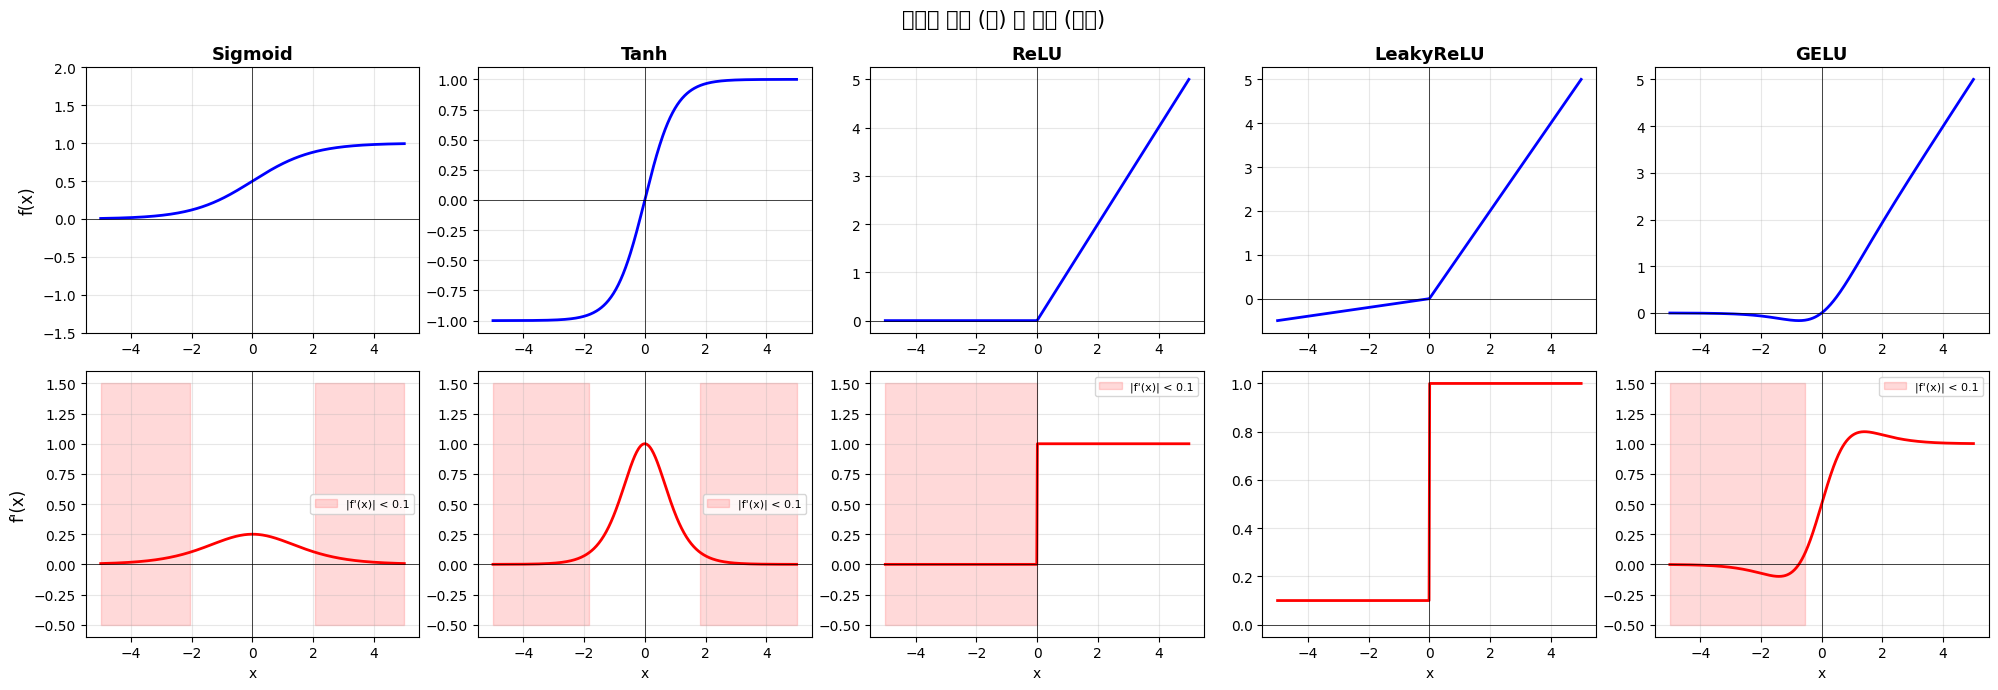

In [11]:
x = torch.linspace(-5, 5, 500)

activations = {
    'Sigmoid':   MySigmoid(),
    'Tanh':      MyTanh(),
    'ReLU':      MyReLU(),
    'LeakyReLU': MyLeakyReLU(alpha=0.1),  # 시각화를 위해 alpha=0.1
    'GELU':      MyGELU(),
}

fig, axes = plt.subplots(2, 5, figsize=(20, 7))

for idx, (name, act) in enumerate(activations.items()):
    y = act.forward(x).detach().numpy()
    dy = act.derivative(x).detach().numpy()

    # Forward
    axes[0][idx].plot(x.numpy(), y, 'b-', linewidth=2)
    axes[0][idx].set_title(f'{name}', fontsize=13, fontweight='bold')
    axes[0][idx].axhline(y=0, color='k', linewidth=0.5)
    axes[0][idx].axvline(x=0, color='k', linewidth=0.5)
    axes[0][idx].grid(True, alpha=0.3)
    if idx == 0:
        axes[0][idx].set_ylabel('f(x)', fontsize=12)

    # Derivative
    axes[1][idx].plot(x.numpy(), dy, 'r-', linewidth=2)
    axes[1][idx].axhline(y=0, color='k', linewidth=0.5)
    axes[1][idx].axvline(x=0, color='k', linewidth=0.5)
    axes[1][idx].grid(True, alpha=0.3)
    if idx == 0:
        axes[1][idx].set_ylabel("f'(x)", fontsize=12)
    axes[1][idx].set_xlabel('x')

    # 포화 구간 하이라이트 (derivative < 0.1인 구간)
    mask = np.abs(dy) < 0.1
    if mask.any():
        axes[1][idx].fill_between(x.numpy(), -0.5, 1.5, where=mask,
                                   alpha=0.15, color='red', label='|f\'(x)| < 0.1')
        axes[1][idx].legend(fontsize=8)

axes[0][0].set_ylim(-1.5, 2)
plt.suptitle('활성화 함수 (위) 와 미분 (아래)', fontsize=15)
plt.tight_layout()
plt.show()

### 3-1. PyTorch Autograd와 미분 검증

직접 구현한 derivative가 맞는지 PyTorch의 자동 미분과 비교합니다.

In [12]:
# Autograd로 수치 검증
x_test = torch.linspace(-3, 3, 100, requires_grad=True)

print("Manual derivative vs PyTorch autograd:")
print(f"{'Activation':<15} {'Max Diff':>10}")
print("-" * 27)

for name, act in activations.items():
    # 직접 구현한 derivative
    my_deriv = act.derivative(x_test.detach())

    # PyTorch autograd
    x_ag = x_test.detach().clone().requires_grad_(True)
    y_ag = act.forward(x_ag)
    y_ag.sum().backward()
    pt_deriv = x_ag.grad

    diff = (my_deriv - pt_deriv).abs().max().item()
    print(f"{name:<15} {diff:>10.2e}")
# 예상: 모두 < 1e-5

Manual derivative vs PyTorch autograd:
Activation        Max Diff
---------------------------
Sigmoid           5.96e-08
Tanh              1.79e-07
ReLU              0.00e+00
LeakyReLU         0.00e+00
GELU              1.19e-07


## 4. MLP 학습 비교 실험

각 활성화 함수를 사용한 MLP로 CIFAR-10을 학습하고 성능을 비교합니다.

여기서는 PyTorch의 `nn.Module`을 사용하되, 우리가 이해한 활성화 함수의 차이가 실제 학습에 어떤 영향을 미치는지 관찰합니다.

In [13]:
class MLP(nn.Module):
    """활성화 함수를 인자로 받는 MLP"""
    def __init__(self, input_dim=3*32*32, hidden_dim=256, num_classes=10, activation=nn.ReLU()):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_dim, hidden_dim),
            activation,
            nn.Linear(hidden_dim, num_classes),
        )
    def forward(self, x):
        return self.net(x)

def train_and_record(model, optimizer, train_loader, val_loader, device, num_epochs=10):
    loss_history, val_acc_history = [], []
    for epoch in range(num_epochs):
        model.train()
        epoch_loss, num_batches = 0.0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model(images), labels)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            num_batches += 1
        loss_history.append(epoch_loss / num_batches)
        val_acc_history.append(evaluate(model, val_loader, device))
    return loss_history, val_acc_history

In [14]:
# 5개 활성화 함수로 학습 비교
act_configs = {
    'Sigmoid':   nn.Sigmoid(),
    'Tanh':      nn.Tanh(),
    'ReLU':      nn.ReLU(),
    'LeakyReLU': nn.LeakyReLU(0.01),
    'GELU':      nn.GELU(),
}

num_epochs = 10
results = {}

for name, act in act_configs.items():
    torch.manual_seed(42)
    model = MLP(activation=act).to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    loss_hist, val_hist = train_and_record(model, optimizer, train_loader, val_loader, device, num_epochs)
    results[name] = {'loss': loss_hist, 'val_acc': val_hist}
    print(f'{name:12s} → Final Loss: {loss_hist[-1]:.4f}, Val Acc: {val_hist[-1]:.4f}')

Sigmoid      → Final Loss: 1.2701, Val Acc: 0.4762
Tanh         → Final Loss: 1.3526, Val Acc: 0.4458
ReLU         → Final Loss: 0.9838, Val Acc: 0.5096
LeakyReLU    → Final Loss: 0.9911, Val Acc: 0.5026
GELU         → Final Loss: 0.9648, Val Acc: 0.5124


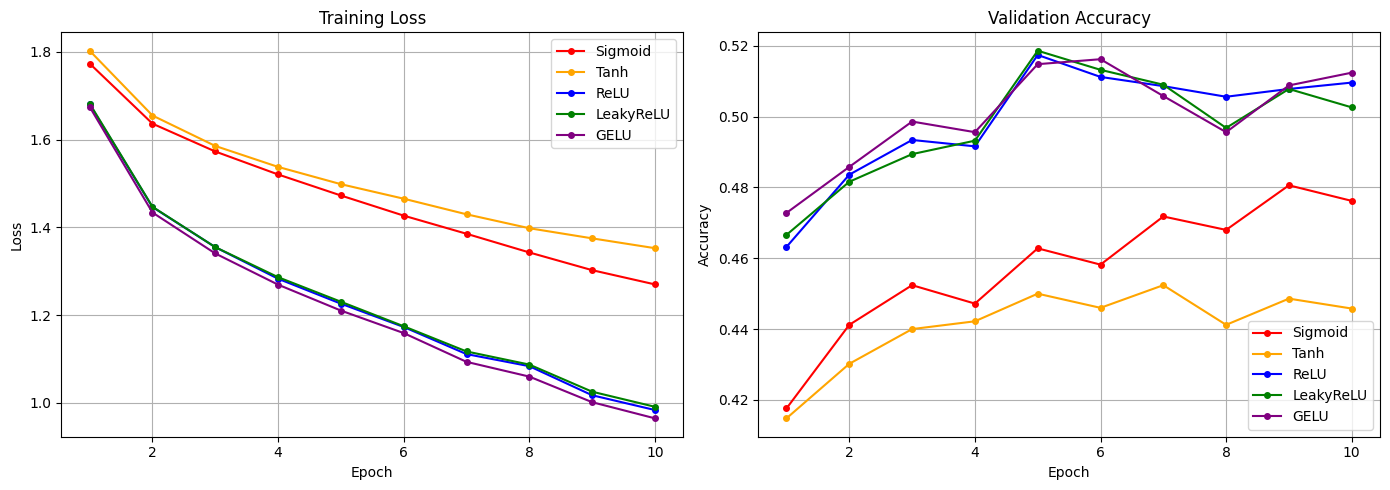

In [15]:
# 학습 비교 시각화
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
colors = {'Sigmoid': 'red', 'Tanh': 'orange', 'ReLU': 'blue', 'LeakyReLU': 'green', 'GELU': 'purple'}
epochs = range(1, num_epochs + 1)

for name, data in results.items():
    ax1.plot(epochs, data['loss'], '-o', color=colors[name], label=name, markersize=4)
    ax2.plot(epochs, data['val_acc'], '-o', color=colors[name], label=name, markersize=4)

ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Training Loss'); ax1.legend(); ax1.grid(True)

ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.set_title('Validation Accuracy'); ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.show()

## 5. Vanishing Gradient & Dead ReLU 분석

### 5-1. 깊은 네트워크에서 Gradient 흐름

3-layer MLP에서 각 layer의 gradient 크기를 측정합니다.
- Sigmoid/Tanh: layer를 지날수록 gradient가 **지수적으로 감소** (vanishing)
 실제로 Tanh은 결과가 다르게 나오긴 하는데, 이론적으로는 지수적으로 감소가 맞음
- ReLU 계열: gradient가 비교적 **일정하게 유지**

/tmp/ipykernel_2988/824524818.py:67: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2988/824524818.py:67: UserWarning: Glyph 53356 (\N{HANGUL SYLLABLE KEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2988/824524818.py:67: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2988/824524818.py:67: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2988/824524818.py:67: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

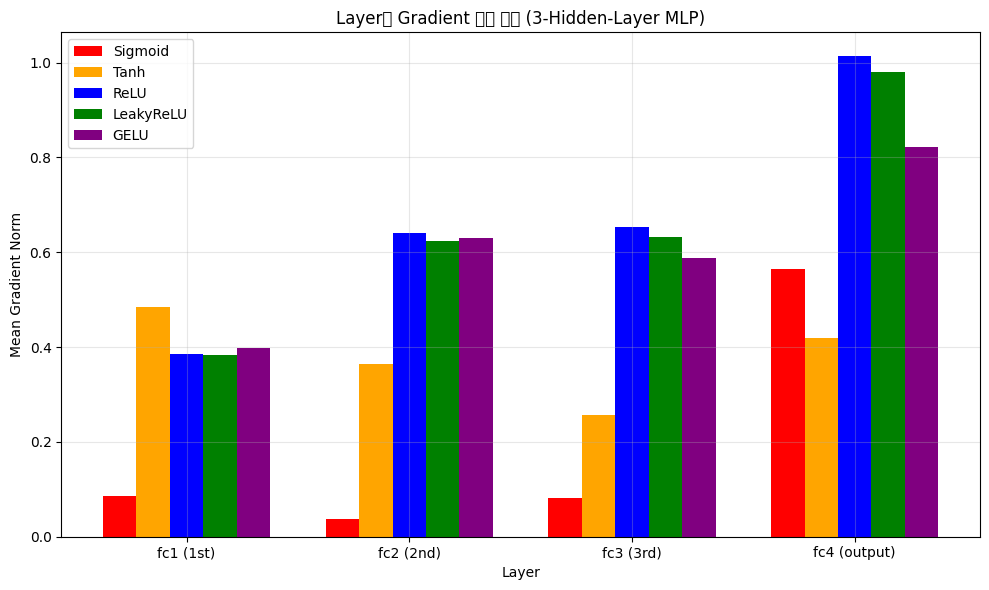

In [16]:
class DeepMLP(nn.Module):
    """3-hidden-layer MLP — gradient 흐름 관찰용"""
    def __init__(self, activation=nn.ReLU()):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(3*32*32, 256)
        self.act1 = activation
        self.fc2 = nn.Linear(256, 256)
        self.act2 = copy.deepcopy(activation) if not isinstance(activation, nn.ReLU) else nn.ReLU()
        self.fc3 = nn.Linear(256, 256)
        self.act3 = copy.deepcopy(activation) if not isinstance(activation, nn.ReLU) else nn.ReLU()
        self.fc4 = nn.Linear(256, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.act1(self.fc1(x))
        x = self.act2(self.fc2(x))
        x = self.act3(self.fc3(x))
        return self.fc4(x)

# 각 활성화 함수별 layer-wise gradient norm 측정
deep_acts = {
    'Sigmoid':   nn.Sigmoid(),
    'Tanh':      nn.Tanh(),
    'ReLU':      nn.ReLU(),
    'LeakyReLU': nn.LeakyReLU(0.01),
    'GELU':      nn.GELU(),
}

grad_norms = {}

for name, act in deep_acts.items():
    torch.manual_seed(42)
    model = DeepMLP(activation=act).to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # 1 epoch만 학습하면서 gradient 수집
    layer_grads = {f'fc{i}': [] for i in range(1, 5)}
    model.train()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(images), labels)
        loss.backward()
        for i, fc in enumerate([model.fc1, model.fc2, model.fc3, model.fc4], 1):
            layer_grads[f'fc{i}'].append(fc.weight.grad.norm().item())
        optimizer.step()

    grad_norms[name] = {k: np.mean(v) for k, v in layer_grads.items()}

# 시각화
fig, ax = plt.subplots(figsize=(10, 6))
x_pos = np.arange(4)
width = 0.15

for idx, (name, norms) in enumerate(grad_norms.items()):
    values = [norms[f'fc{i}'] for i in range(1, 5)]
    ax.bar(x_pos + idx * width, values, width, label=name, color=colors[name])

ax.set_xlabel('Layer')
ax.set_ylabel('Mean Gradient Norm')
ax.set_title('Layer별 Gradient 크기 비교 (3-Hidden-Layer MLP)')
ax.set_xticks(x_pos + width * 2)
ax.set_xticklabels(['fc1 (1st)', 'fc2 (2nd)', 'fc3 (3rd)', 'fc4 (output)'])
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 5-2. Dead ReLU 문제 시각화

ReLU는 $x < 0$이면 gradient가 0입니다. 만약 큰 negative bias 때문에 뉴런의 입력이 항상 음수가 되면, 그 뉴런은 **영원히 업데이트되지 않습니다** (Dead Neuron).

아래에서 학습 전후의 ReLU 뉴런 활성화 비율을 비교합니다.

In [ ]:
# Dead ReLU 분석: 학습 후 hidden layer 뉴런 중 "항상 0인" 비율
torch.manual_seed(42)
model_relu = DeepMLP(activation=nn.ReLU()).to(device)
optimizer = optim.SGD(model_relu.parameters(), lr=0.01)  # SGD는 dead neuron이 더 잘 발생

# 학습 전 활성화 비율 측정
def measure_dead_neurons(model, data_loader, device):
    """각 hidden layer에서 항상 0인(dead) 뉴런의 비율을 측정"""
    model.eval()
    activations = {1: [], 2: [], 3: []}
    hooks = []

    def make_hook(layer_idx):
        def hook(module, input, output):
            activations[layer_idx].append((output > 0).float().cpu())
        return hook

    hooks.append(model.act1.register_forward_hook(make_hook(1)))
    hooks.append(model.act2.register_forward_hook(make_hook(2)))
    hooks.append(model.act3.register_forward_hook(make_hook(3)))

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            model(images)
            if len(activations[1]) >= 10:  # 10 배치만 샘플링
                break

    for h in hooks:
        h.remove()

    dead_ratios = {}
    for layer_idx, acts in activations.items():
        all_acts = torch.cat(acts, dim=0)  # (N_samples, hidden_dim)
        # 모든 샘플에서 한 번도 활성화되지 않은 뉴런
        never_active = (all_acts.mean(dim=0) == 0).float().mean().item()
        dead_ratios[f'Layer {layer_idx}'] = never_active * 100
    return dead_ratios

print("=== Dead Neuron Ratio (Before Training) ===")
dead_before = measure_dead_neurons(model_relu, train_loader, device)
for layer, ratio in dead_before.items():
    print(f"  {layer}: {ratio:.1f}%")

# 10 epoch 학습
for epoch in range(10):
    model_relu.train()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        criterion(model_relu(images), labels).backward()
        optimizer.step()

print("\n=== Dead Neuron Ratio (After Training) ===")
dead_after = measure_dead_neurons(model_relu, train_loader, device)
for layer, ratio in dead_after.items():
    print(f"  {layer}: {ratio:.1f}%")

# 시각화
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
layers = list(dead_before.keys())

ax1.bar(layers, dead_before.values(), color=['skyblue']*3)
ax1.set_ylabel('Dead Neuron 비율 (%)')
ax1.set_title('학습 전')
ax1.set_ylim(0, max(max(dead_before.values()), max(dead_after.values())) * 1.3 + 5)

ax2.bar(layers, dead_after.values(), color=['salmon']*3)
ax2.set_ylabel('Dead Neuron 비율 (%)')
ax2.set_title('학습 후 (SGD, 10 epochs)')
ax2.set_ylim(0, max(max(dead_before.values()), max(dead_after.values())) * 1.3 + 5)

plt.suptitle('ReLU Dead Neuron 분석', fontsize=14)
plt.tight_layout()
plt.show()

### 정리

| 활성화 함수 | 장점 | 단점 | 사용처 |
|------------|------|------|--------|
| **Sigmoid** | 확률 해석 가능 (0~1) | vanishing gradient, not zero-centered | 이진 분류 출력층 |
| **Tanh** | zero-centered, Sigmoid보다 gradient 큼 | 여전히 vanishing gradient | RNN (역사적) |
| **ReLU** | 빠른 계산, gradient 유지 | Dead ReLU 문제 | CNN 기본값 |
| **LeakyReLU** | Dead ReLU 해결 | α 하이퍼파라미터 추가 | ReLU 대안 |
| **GELU** | 부드러운 전환, 최고 성능 | 약간 느린 계산 | Transformer (GPT, BERT, ViT) |

> **실무 팁**: 기본적으로 **ReLU** 또는 **GELU**를 사용하고, Dead ReLU가 의심되면 **LeakyReLU**로 전환하세요. Sigmoid와 Tanh는 hidden layer에서는 거의 사용하지 않지만, 출력층에서는 여전히 중요합니다 (Sigmoid: 이진분류, Tanh: 값 범위 제한).